# Experimental Data Evaluation — ORNL NR Samples

Runs inference on 7 real ORNL neutron reflectivity measurements using the trained 6-layer CNN model (Trial 12: layers=6, dropout=0.107, batch_size=64).

The difference between this and reflectivity_pipeline.ipynb (synthetic)

Loads NR and SLD from the 30k synthetic training data (nr_train.npy, sld_train.npy)
Data is already in the exact format the model expects: (N, 2, 308) and (N, 2, 900)
No preprocessing needed — just slice and run
reflectivity_pipeline_experimental.ipynb (ORNL)

Loads the 7 real ORNL .npy files from experimental_data/
Had to preprocess each file because real data isn't pre-formatted:
Transpose NR from (N, 2) → (2, N) — the model wants channels first
Transpose SLD from (L, 2) → (2, L) — same reason
Interpolate SLD to exactly 900 points — the ORNL SLD files have a different number of depth points than what the model outputs
Flip the SLD with reverse_y_order() — ORNL measures from air → substrate, but the training data is oriented substrate → air
Zero-shift the depth axis so it starts at 0

## 1. Environment Check

In [1]:
import platform, sys, importlib

def safe_version(pkg):
    try:
        module = importlib.import_module(pkg)
        return getattr(module, '__version__', 'unknown')
    except ModuleNotFoundError:
        return 'not installed'

print(f'Python: {sys.version.split()[0]} ({platform.system()} {platform.release()})')
print(f'PyTorch: {safe_version("torch")}')

try:
    import torch
    print('CUDA available:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('CUDA device:', torch.cuda.get_device_name(0))
except ModuleNotFoundError:
    pass

Python: 3.10.19 (Windows 10)


PyTorch: 2.5.1+cpu
CUDA available: False


## 2. Paths

In [2]:
from pathlib import Path
import numpy as np

EXP_ROOT    = Path('C:/Users/rahej/Documents/Programming/Northeastern/CS 2535/pyreflect-new-overfitting/experiments/best_model_30k_6L_0.107D')
ORNL_FOLDER = Path('C:/Users/rahej/Documents/Programming/Northeastern/CS 2535/pyreflect-new-overfitting/experimental_data')

MODEL_PATH = EXP_ROOT / 'trained_model.pth'
NORM_STAT  = EXP_ROOT / 'data/normalization_stat.npy'

for p in [MODEL_PATH, NORM_STAT, ORNL_FOLDER]:
    status = 'OK' if p.exists() else f'MISSING: {p}'
    print(status)

OK
OK
OK


## 3. Inspect Raw File Shapes

Before any reshaping — print the raw shape and a data sample from each file type so we know exactly what format they're in.

In [3]:
import glob, os

nr_files  = sorted(glob.glob(str(ORNL_FOLDER / 'np_out_REFL_*_combined_data_auto.npy')))
sld_files = sorted(glob.glob(str(ORNL_FOLDER / 'sld_REF_L_*.npy')))

print(f'Found {len(nr_files)} NR files, {len(sld_files)} SLD files')
print()

print('--- NR files ---')
for f in nr_files:
    arr = np.load(f)
    print(f'  {os.path.basename(f)}')
    print(f'    shape: {arr.shape}, dtype: {arr.dtype}')
    print(f'    sample (first row): {arr[0]}')
    print()

print('--- SLD files ---')
for f in sld_files:
    arr = np.load(f)
    print(f'  {os.path.basename(f)}')
    print(f'    shape: {arr.shape}, dtype: {arr.dtype}')
    print(f'    sample (first row): {arr[0]}')
    print()

Found 7 NR files, 7 SLD files

--- NR files ---
  np_out_REFL_194438_combined_data_auto.npy
    shape: (308, 2), dtype: float64
    sample (first row): [0.00810144 0.88799593]

  np_out_REFL_194446_combined_data_auto.npy
    shape: (308, 2), dtype: float64
    sample (first row): [0.00810144 0.7465575 ]

  np_out_REFL_194455_combined_data_auto.npy
    shape: (308, 2), dtype: float64
    sample (first row): [0.00810144 0.77964082]

  np_out_REFL_194463_combined_data_auto.npy
    shape: (308, 2), dtype: float64
    sample (first row): [0.00810144 0.93027772]

  np_out_REFL_194471_combined_data_auto.npy
    shape: (308, 2), dtype: float64
    sample (first row): [0.00810144 0.83286702]

  np_out_REFL_194479_combined_data_auto.npy
    shape: (308, 2), dtype: float64
    sample (first row): [0.00810144 0.87806455]

  np_out_REFL_194487_combined_data_auto.npy
    shape: (308, 2), dtype: float64
    sample (first row): [0.00810144 0.86924948]

--- SLD files ---
  sld_REF_L_194438.npy
    shap

## 4. Load Model

In [4]:
import pyreflect
import pyreflect.pipelines.reflectivity_pipeline as workflow
from pyreflect.config import load_config
from pyreflect.models.config import NRSLDModelTrainerParams

root   = str(EXP_ROOT)
config = load_config(root)

model_config = config['nr_predict_sld']['models']
model_config['layers']              = 6
model_config['dropout']             = 0.107
model_config['model']               = MODEL_PATH
model_config['normalization_stats'] = NORM_STAT

file_config = config['nr_predict_sld']['file']
file_config['nr_train']  = str(EXP_ROOT / 'data/curves/nr_train.npy')
file_config['sld_train'] = str(EXP_ROOT / 'data/curves/sld_train.npy')

trainer_params = NRSLDModelTrainerParams(root, _config=config)

pipeline   = workflow.ReflectivityPipeline(None, trainer_params)
model      = pipeline.load_model(str(MODEL_PATH))
norm_stats = workflow.load_normalization_stat(str(NORM_STAT))
print('Model and norm stats loaded.')

Selected device for model training: cpu


C:\Users\rahej\Documents\Programming\Northeastern\CS 2535\pyreflect-new-overfitting\src\pyreflect\pipelines\reflectivity_pipeline.py:245: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental 

Loaded NR predict SLD model from: C:\Users\rahej\Documents\Programming\Northeastern\CS 2535\pyreflect-new-overfitting\experiments\best_model_30k_6L_0.107D\trained_model.pth


Model and norm stats loaded.


## 5. Preprocess Experimental Data

After inspecting shapes above, we:
- Transpose NR from `(N, 2)` → `(2, N)` (row 0 = Q, row 1 = R)
- Transpose SLD from `(L, 2)` → `(2, L)` (row 0 = depth z, row 1 = SLD ρ)
- Interpolate SLD to exactly 900 points (model output length)
- Flip SLD orientation with `reverse_y_order` (substrate → air, matching training data convention)
- Zero-shift the depth axis

In [5]:
from pyreflect.pipelines.helper import reverse_y_order

TARGET_LEN = 900

nr_batch  = []
true_sld  = []
sample_ids = []

for nr_f, sld_f in zip(nr_files, sld_files):
    sample_id = os.path.basename(nr_f).split('_')[3]   # e.g. '194438'
    sample_ids.append(sample_id)

    nr  = np.load(nr_f)   # raw shape printed above
    sld = np.load(sld_f)  # raw shape printed above

    # Ensure (2, N) layout — transpose if rows are samples
    if nr.ndim == 2 and nr.shape[1] == 2:
        nr = nr.T    # (N,2) → (2,N)
    if sld.ndim == 2 and sld.shape[1] == 2:
        sld = sld.T  # (L,2) → (2,L)

    # Interpolate SLD depth axis to TARGET_LEN
    L = sld.shape[1]
    x_old = np.linspace(0, 1, L)
    x_new = np.linspace(0, 1, TARGET_LEN)
    sld_interp = np.array([np.interp(x_new, x_old, sld[ch]) for ch in range(2)])

    # Flip SLD so orientation goes substrate → air (matches training data)
    sld_interp = reverse_y_order(sld_interp)
    # Zero-shift depth axis
    sld_interp[0] = sld_interp[0] - sld_interp[0].min()

    nr_batch.append(nr)
    true_sld.append(sld_interp)

nr_batch = np.array(nr_batch)   # (7, 2, N)
true_sld = np.array(true_sld)   # (7, 2, 900)

print('NR batch shape: ', nr_batch.shape)
print('True SLD shape:', true_sld.shape)
print('Sample IDs:    ', sample_ids)

NR batch shape:  (7, 2, 308)
True SLD shape: (7, 2, 900)
Sample IDs:     ['194438', '194446', '194455', '194463', '194471', '194479', '194487']


## 6. Run Inference

In [6]:
y_pred = pipeline.predict_sld(nr_batch, norm_stats, model)
y_pred = np.asarray(y_pred)
print('Predictions shape:', y_pred.shape)

Predicted SLD shape: (7, 2, 900)


Predictions shape: (7, 2, 900)


## 7. Recompute NR from Predicted SLD

Back-calculates reflectivity from the predicted SLD so we can overlay it on the experimental NR curve.

In [7]:
from pyreflect.pipelines import compute_nr_from_sld

computed_nr = []
for i in range(len(nr_batch)):
    Q, R = compute_nr_from_sld(y_pred[i])
    computed_nr.append(np.stack([Q, R]))
computed_nr = np.stack(computed_nr)
print('Computed NR shape:', computed_nr.shape)

Computed NR shape: (7, 2, 400)


## 8. Plot Results

One figure per sample. Left: experimental NR vs recomputed NR. Right: ground truth SLD vs predicted SLD.

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Sans'

def plot_experiment_results(expt_nr_data, expt_sld_data=None,
                            computed_nr_data=None, predicted_sld_data=None,
                            title=None):
    mpl.rcParams.update({
        'font.size': 8,
        'axes.labelsize': 9,
        'axes.titlesize': 9,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'lines.linewidth': 1.3,
        'figure.dpi': 150,
    })

    fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.6))

    if title:
        fig.suptitle(title, fontsize=9, y=1.02)

    # Left: NR
    axes[0].plot(expt_nr_data[0], expt_nr_data[1],
                 color='black', linestyle='-', linewidth=2, label='Experimental')
    if computed_nr_data is not None:
        axes[0].plot(computed_nr_data[0], computed_nr_data[1],
                     color='red', linestyle='--', linewidth=1.3, label='From Pred SLD')
    axes[0].set_xlabel('Q (Å⁻¹)')
    axes[0].set_ylabel('Reflectivity NR')
    axes[0].set_yscale('log')
    axes[0].legend(frameon=False, loc='upper right', handlelength=2.5)

    # Right: SLD
    if expt_sld_data is not None:
        axes[1].plot(expt_sld_data[0], expt_sld_data[1],
                     color='black', linestyle='-', linewidth=2, label='ORNL Ground Truth')
    if predicted_sld_data is not None:
        axes[1].plot(predicted_sld_data[0], predicted_sld_data[1],
                     color='red', linestyle='--', linewidth=1.3, label='Predicted')
    axes[1].set_xlabel('Depth (Å)')
    axes[1].set_ylabel('SLD (×10⁻⁶ Å⁻²)')
    axes[1].legend(frameon=False, loc='upper right', handlelength=2.5)

    for ax in axes:
        ax.set_title('')
        ax.tick_params(direction='in', length=2.5)

    plt.tight_layout(pad=1.0, w_pad=1.4)
    plt.show()
    return fig

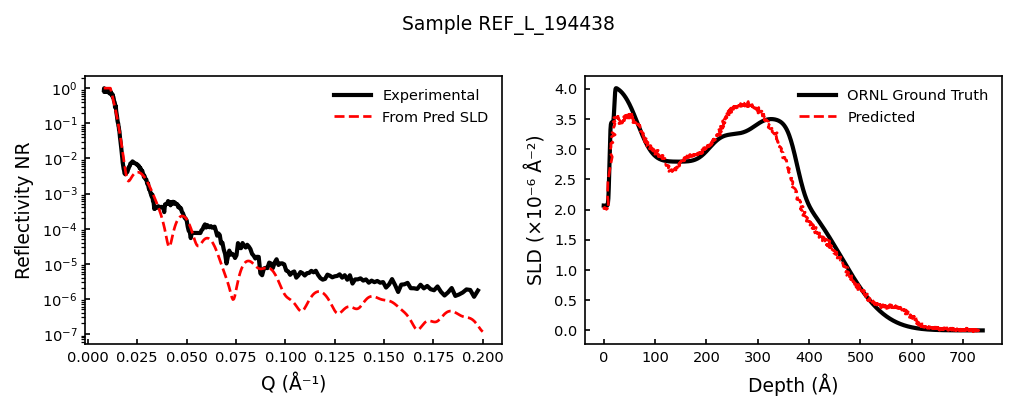

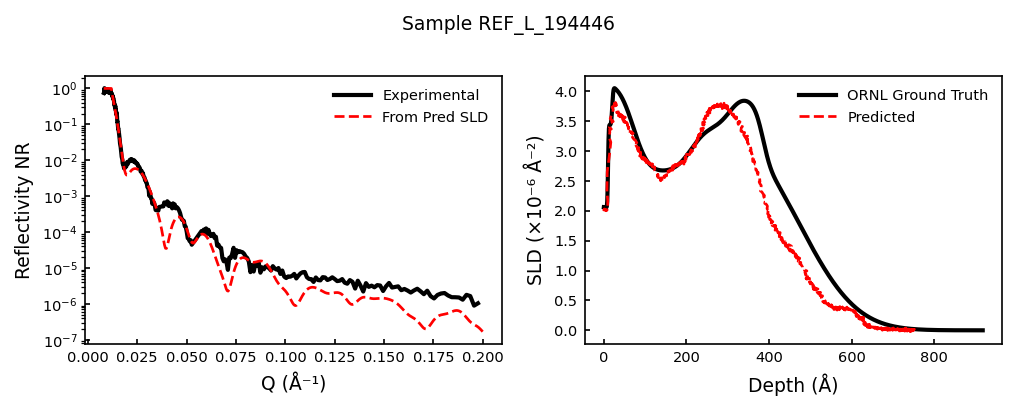

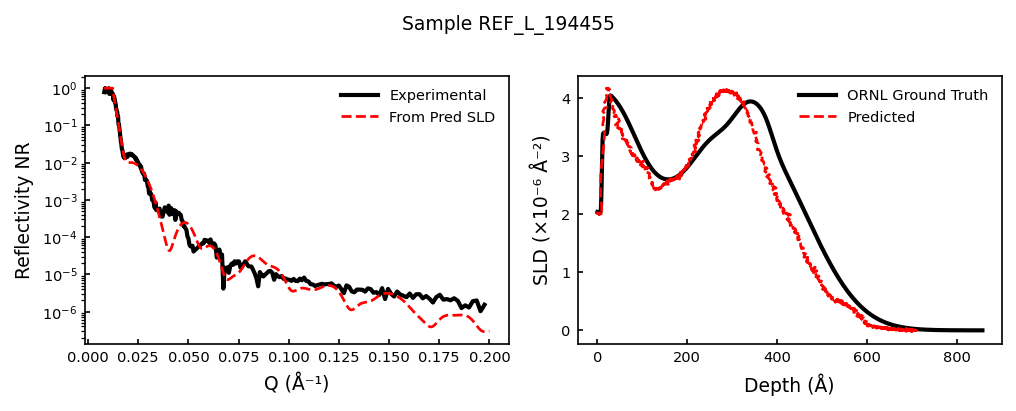

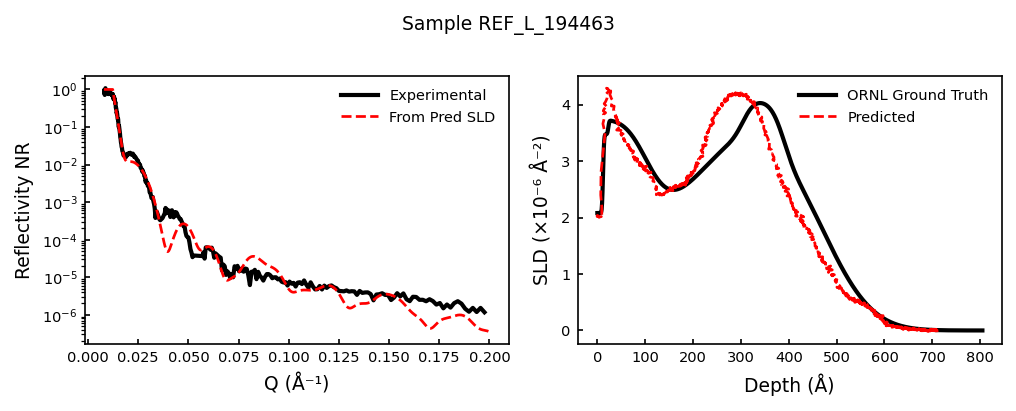

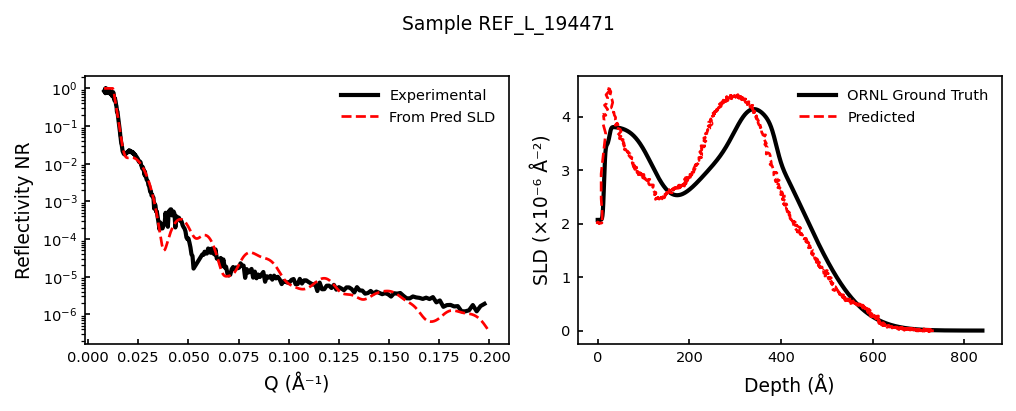

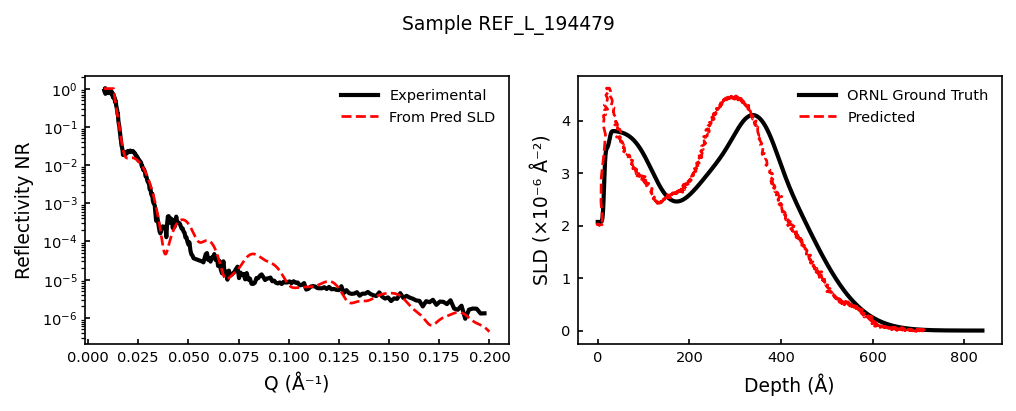

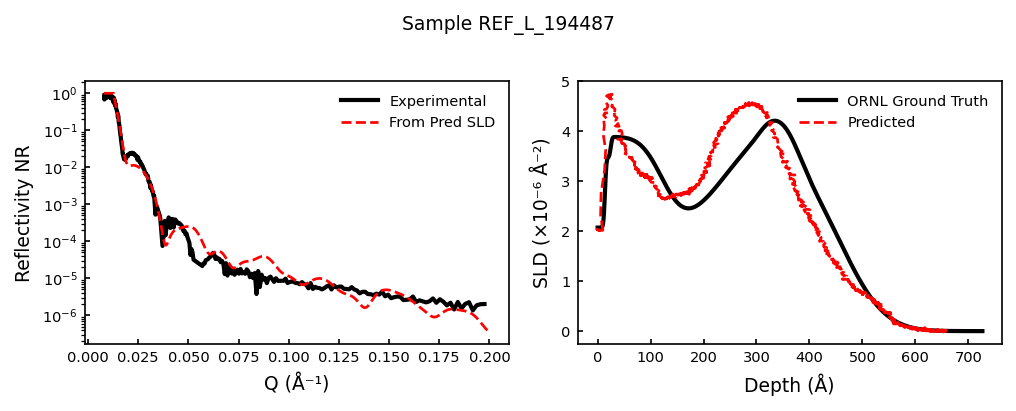

In [9]:
%matplotlib inline

for i, sid in enumerate(sample_ids):
    plot_experiment_results(
        expt_nr_data      = nr_batch[i],
        expt_sld_data     = true_sld[i],
        computed_nr_data  = computed_nr[i],
        predicted_sld_data= y_pred[i],
        title             = f'Sample REF_L_{sid}'
    )

## 9. R² Scores

In [10]:
def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 0.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)

def align_arrays(true_arr, pred_arr):
    """Interpolate pred onto the x-grid of true. Both shape (2, N)."""
    y_aligned = np.interp(true_arr[0], pred_arr[0], pred_arr[1])
    return np.vstack((true_arr[0], y_aligned))

print(f'{"Sample":<12} | {"R² SLD":<10} | {"R² NR":<10}')
print('-' * 38)
r2_sld_list, r2_nr_list = [], []

for i, sid in enumerate(sample_ids):
    aligned_sld = align_arrays(true_sld[i],  y_pred[i])
    aligned_nr  = align_arrays(nr_batch[i],  computed_nr[i])

    r2_sld = compute_r2(true_sld[i][1], aligned_sld[1])
    r2_nr  = compute_r2(nr_batch[i][1],  aligned_nr[1])

    r2_sld_list.append(r2_sld)
    r2_nr_list.append(r2_nr)
    print(f'{sid:<12} | {r2_sld:<10.4f} | {r2_nr:<10.4f}')

print('-' * 38)
print(f'{"AVERAGE":<12} | {np.mean(r2_sld_list):<10.4f} | {np.mean(r2_nr_list):<10.4f}')

Sample       | R² SLD     | R² NR     
--------------------------------------
194438       | 0.9737     | 0.9660    
194446       | 0.9362     | 0.9579    
194455       | 0.9270     | 0.9463    
194463       | 0.9311     | 0.9348    
194471       | 0.9339     | 0.9225    
194479       | 0.9181     | 0.9243    
194487       | 0.8832     | 0.9308    
--------------------------------------
AVERAGE      | 0.9290     | 0.9404    
